### Section 1: Purpose

### Feature Extraction Demo

This notebook demonstrates two core feature extraction steps commonly used in resting-state fMRI machine learning workflows:

1. Functional connectivity extraction
2. ALFF-style low-frequency signal feature extraction

The data used here is simulated fMRI-like ROI time-series data. It is not real patient data. The goal is to demonstrate implementation ability, not clinical prediction.

### Imports

In [1]:
import sys
import os
from pathlib import Path

# Change working directory to project root if running from notebooks directory
if Path.cwd().name == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path(".").resolve()))

from src.connectivity import (
    compute_connectivity_matrix,
    flatten_upper_triangle,
    create_connectivity_feature_names
)

from src.alff import (
    compute_alff,
    create_alff_feature_names
)

### Simulate fMRI-like ROI time series

In [2]:
np.random.seed(42)

n_timepoints = 200
region_names = [
    "right_temporal",
    "left_temporal",
    "right_occipital",
    "left_occipital",
    "cerebellum",
    "right_parietal",
    "frontal",
    "insula"
]

n_regions = len(region_names)

# Base noise
timeseries = np.random.normal(0, 1, size=(n_timepoints, n_regions))

# Add shared signal patterns to create realistic correlations
shared_temporal_occipital_signal = np.sin(np.linspace(0, 8 * np.pi, n_timepoints))
shared_cerebellum_signal = np.cos(np.linspace(0, 6 * np.pi, n_timepoints))

timeseries[:, 0] += 0.6 * shared_temporal_occipital_signal  # right_temporal
timeseries[:, 1] += 0.5 * shared_temporal_occipital_signal  # left_temporal
timeseries[:, 2] += 0.4 * shared_temporal_occipital_signal  # right_occipital
timeseries[:, 3] += 0.4 * shared_temporal_occipital_signal  # left_occipital
timeseries[:, 4] += 0.5 * shared_cerebellum_signal          # cerebellum
timeseries[:, 5] += 0.3 * shared_cerebellum_signal          # right_parietal

timeseries_df = pd.DataFrame(timeseries, columns=region_names)
timeseries_df.head()

,right_temporal,left_temporal,right_occipital,left_occipital,cerebellum,right_parietal,frontal,insula
0,0.496714,-0.138264,0.647689,1.523030,0.265847,0.065863,1.579213,0.767435
1,-0.393899,0.605540,-0.413034,-0.415346,0.739721,-1.614625,-1.724918,-0.562288
2,-0.862883,0.439204,-0.808059,-1.312339,1.956703,0.068856,0.067528,-1.424748
3,-0.322452,0.295865,-1.003039,0.523652,-0.120691,-0.003725,-0.601707,1.852278
4,0.276882,-0.815728,1.016131,-1.027257,0.673402,-1.680947,-1.328186,0.196861


### Plot ROI Signals

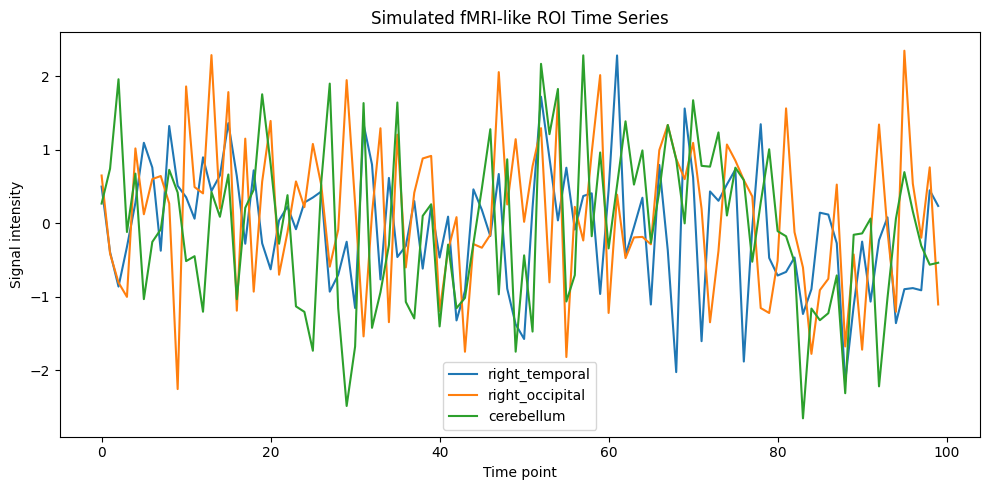

In [3]:
plt.figure(figsize=(10, 5))

for region in ["right_temporal", "right_occipital", "cerebellum"]:
    plt.plot(timeseries_df[region].values[:100], label=region)

plt.title("Simulated fMRI-like ROI Time Series")
plt.xlabel("Time point")
plt.ylabel("Signal intensity")
plt.legend()
plt.tight_layout()
plt.show()

### Compute connectivity matrix

In [4]:
connectivity_matrix = compute_connectivity_matrix(timeseries)

connectivity_df = pd.DataFrame(
    connectivity_matrix,
    index=region_names,
    columns=region_names
)

connectivity_df

,right_temporal,left_temporal,right_occipital,left_occipital,cerebellum,right_parietal,frontal,insula
right_temporal,1.000000,0.100587,0.072551,0.092929,-0.008510,-0.036531,-0.119270,-0.089495
left_temporal,0.100587,1.000000,0.072200,0.148890,0.077426,-0.091693,-0.014767,0.149607
right_occipital,0.072551,0.072200,1.000000,0.006584,-0.024511,-0.128106,-0.012520,0.002384
left_occipital,0.092929,0.148890,0.006584,1.000000,-0.160655,-0.072026,0.095146,0.083091
cerebellum,-0.008510,0.077426,-0.024511,-0.160655,1.000000,0.027390,-0.048971,0.041916
right_parietal,-0.036531,-0.091693,-0.128106,-0.072026,0.027390,1.000000,0.002262,0.009086
frontal,-0.119270,-0.014767,-0.012520,0.095146,-0.048971,0.002262,1.000000,0.114499
insula,-0.089495,0.149607,0.002384,0.083091,0.041916,0.009086,0.114499,1.000000


### Save connectivity heatmap

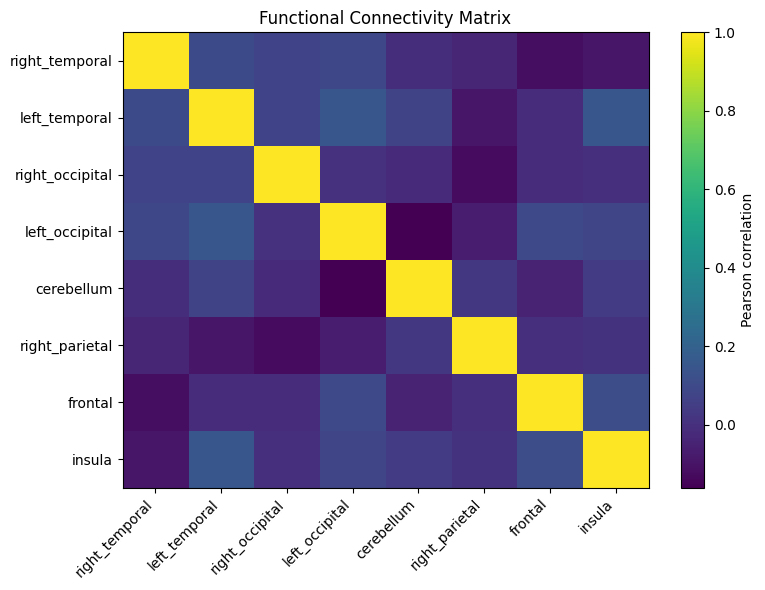

In [5]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 6))
plt.imshow(connectivity_matrix, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(n_regions), region_names, rotation=45, ha="right")
plt.yticks(range(n_regions), region_names)
plt.title("Functional Connectivity Matrix")
plt.tight_layout()
plt.savefig(output_dir / "connectivity_heatmap.png", dpi=300)
plt.show()

### Flatten connectivity matrix into features

In [6]:
connectivity_vector = flatten_upper_triangle(connectivity_matrix)
connectivity_feature_names = create_connectivity_feature_names(region_names)

connectivity_features = pd.DataFrame(
    [connectivity_vector],
    columns=connectivity_feature_names
)

connectivity_features.head()

,right_temporal__left_temporal_connectivity,right_temporal__right_occipital_connectivity,right_temporal__left_occipital_connectivity,right_temporal__cerebellum_connectivity,right_temporal__right_parietal_connectivity,right_temporal__frontal_connectivity,right_temporal__insula_connectivity,left_temporal__right_occipital_connectivity,left_temporal__left_occipital_connectivity,left_temporal__cerebellum_connectivity,...,left_occipital__cerebellum_connectivity,left_occipital__right_parietal_connectivity,left_occipital__frontal_connectivity,left_occipital__insula_connectivity,cerebellum__right_parietal_connectivity,cerebellum__frontal_connectivity,cerebellum__insula_connectivity,right_parietal__frontal_connectivity,right_parietal__insula_connectivity,frontal__insula_connectivity
0,0.100587,0.072551,0.092929,-0.00851,-0.036531,-0.11927,-0.089495,0.0722,0.14889,0.077426,...,-0.160655,-0.072026,0.095146,0.083091,0.02739,-0.048971,0.041916,0.002262,0.009086,0.114499


### Compute ALFF-style features

In [7]:
alff_values = compute_alff(
    timeseries,
    tr=2.0,
    low_freq=0.01,
    high_freq=0.10
)

alff_feature_names = create_alff_feature_names(region_names)

alff_features = pd.DataFrame(
    [alff_values],
    columns=alff_feature_names
)

alff_features

,right_temporal_alff,left_temporal_alff,right_occipital_alff,left_occipital_alff,cerebellum_alff,right_parietal_alff,frontal_alff,insula_alff
0,12.357911,13.148925,12.177748,13.620535,11.516088,13.336159,12.578144,11.767918


### Combine feature vector

In [8]:
combined_features = pd.concat(
    [connectivity_features, alff_features],
    axis=1
)

combined_features.head()

,right_temporal__left_temporal_connectivity,right_temporal__right_occipital_connectivity,right_temporal__left_occipital_connectivity,right_temporal__cerebellum_connectivity,right_temporal__right_parietal_connectivity,right_temporal__frontal_connectivity,right_temporal__insula_connectivity,left_temporal__right_occipital_connectivity,left_temporal__left_occipital_connectivity,left_temporal__cerebellum_connectivity,...,right_parietal__insula_connectivity,frontal__insula_connectivity,right_temporal_alff,left_temporal_alff,right_occipital_alff,left_occipital_alff,cerebellum_alff,right_parietal_alff,frontal_alff,insula_alff
0,0.100587,0.072551,0.092929,-0.00851,-0.036531,-0.11927,-0.089495,0.0722,0.14889,0.077426,...,0.009086,0.114499,12.357911,13.148925,12.177748,13.620535,11.516088,13.336159,12.578144,11.767918


### Interpretation

The final feature vector combines connectivity-style and ALFF-style features. In a real neuroimaging workflow, these subject-level features could be combined with lesion-volume features and used for model training, evaluation, and inference.

This mirrors the general research workflow of transforming raw imaging or time-series data into interpretable numerical features that can be used in downstream machine learning models.